# 05 — Deep Learning, Sequence Model on Mouse / Keystroke Streams

> **Synthetic data warning.** The production behavioural-biometrics
> corpus does not exist yet — it requires live traffic on the deployed
> Detection Service (`bot-detection/services/detection`). For this
> notebook we synthesise plausible mouse and keystroke streams from
> each row's label using `rexell_ml.synth.make_sequence_dataset(...)`.
>
> Human sequences: smooth Fourier-summed mouse trajectories with
> jitter, lognormal keystroke timing.
> Bot sequences: piecewise-linear paths with deterministic timing.

Architecture (identical in both PyTorch and Keras):

```
Input(T=200, C=6)
    → Conv1D(32, k=5) + BN + ReLU + MaxPool(2)
    → Conv1D(64, k=3) + BN + ReLU + MaxPool(2)
    → Bidirectional LSTM(32) → mean pool over time
    → Dense(32) + Dropout(0.3) → Dense(1, sigmoid)
```

Channels: `[t_mouse, x_norm, y_norm, t_key, dwell, flight]`.


## Imports


In [1]:
import sys, pathlib, os, warnings, time

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import tensorflow as tf
from tensorflow import keras

from rexell_ml import data, synth, metrics

data.set_seed(42)

MODELS_DIR = pathlib.Path("..") / "models"
REPORTS_DIR = pathlib.Path("..") / "reports"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__, "tf:", tf.__version__, "device:", DEVICE)


torch: 2.11.0+cu130 tf: 2.17.1 device: cpu


## Generate synthetic sequences

We pull labels from the wallet-level split persisted by notebook 02 and
synthesise a (T=200, C=6) tensor per wallet. Same train / val / test
partitions.


In [2]:
split = data.load_split("master_features")
# We only need labels here; the sequence inputs are synthesised below.
y_train = split.y_train.values.astype(np.int64)
y_val   = split.y_val.values.astype(np.int64)
y_test  = split.y_test.values.astype(np.int64)

X_train, _ = synth.make_sequence_dataset(y_train, length=synth.SEQ_LEN, seed=11)
X_val,   _ = synth.make_sequence_dataset(y_val,   length=synth.SEQ_LEN, seed=22)
X_test,  _ = synth.make_sequence_dataset(y_test,  length=synth.SEQ_LEN, seed=33)

print("train:", X_train.shape, "  val:", X_val.shape, "  test:", X_test.shape)
print("pos pct train:", round(float(y_train.mean()), 4))


train: (2996, 200, 6)   val: (643, 200, 6)   test: (643, 200, 6)
pos pct train: 0.0164


### Visualise a synthetic human vs synthetic bot trajectory


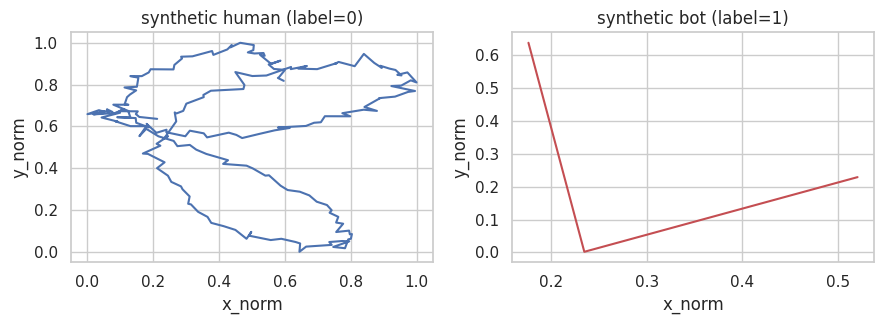

In [3]:
idx_human = int(np.where(y_train == 0)[0][0])
idx_bot = int(np.where(y_train == 1)[0][0])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].plot(X_train[idx_human, :, 1], X_train[idx_human, :, 2], color="C0")
axes[0].set_title(f"synthetic human (label=0)")
axes[0].set_xlabel("x_norm"); axes[0].set_ylabel("y_norm")

axes[1].plot(X_train[idx_bot, :, 1], X_train[idx_bot, :, 2], color="C3")
axes[1].set_title(f"synthetic bot (label=1)")
axes[1].set_xlabel("x_norm"); axes[1].set_ylabel("y_norm")
fig.tight_layout()


## 5.1 — PyTorch Conv1D + BiLSTM


In [4]:
from sklearn.metrics import f1_score, roc_auc_score

SEQ_LEN, N_CH = X_train.shape[1], X_train.shape[2]

class TorchSeqModel(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(64, 32, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # x: (B, T, C) → conv expects (B, C, T)
        z = self.conv(x.transpose(1, 2))      # (B, 64, T/4)
        z = z.transpose(1, 2)                  # (B, T/4, 64)
        z, _ = self.lstm(z)                    # (B, T/4, 64)
        z = z.mean(dim=1)                      # (B, 64)
        return self.head(z).squeeze(-1)


torch_seq = TorchSeqModel(N_CH).to(DEVICE)
print(torch_seq)


TorchSeqModel(
  (conv): Sequential(
    (0): Conv1d(6, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(64, 32, batch_first=True, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [5]:
train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    ),
    batch_size=256, shuffle=True,
)

X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
X_te_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)

pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=DEVICE))
opt = torch.optim.Adam(torch_seq.parameters(), lr=1e-3)

history_torch = {"loss": [], "val_f1": [], "val_auc": []}
best_state, best_f1, patience, max_patience, max_epochs = None, -1, 0, 5, 25

t0 = time.time()
for epoch in range(1, max_epochs + 1):
    torch_seq.train()
    ep_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        logits = torch_seq(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        ep_loss += float(loss) * len(xb)
    ep_loss /= len(train_loader.dataset)

    torch_seq.eval()
    with torch.no_grad():
        p_val = torch.sigmoid(torch_seq(X_val_t)).cpu().numpy()
    f1 = float(f1_score(y_val, (p_val >= 0.5).astype(int), zero_division=0))
    auc = float(roc_auc_score(y_val, p_val)) if len(np.unique(y_val)) > 1 else float("nan")
    history_torch["loss"].append(ep_loss)
    history_torch["val_f1"].append(f1)
    history_torch["val_auc"].append(auc)

    if f1 > best_f1:
        best_f1 = f1
        best_state = {k: v.clone().detach() for k, v in torch_seq.state_dict().items()}
        patience = 0
    else:
        patience += 1
    print(f"  ep {epoch:>3d}  loss={ep_loss:.4f}  val_F1={f1:.4f}  val_AUC={auc:.4f}")
    if patience >= max_patience:
        print(f"  early stopping (best F1 {best_f1:.4f})")
        break

torch_seq.load_state_dict(best_state)
print(f"trained in {time.time()-t0:.1f}s")


  ep   1  loss=1.3105  val_F1=0.0000  val_AUC=1.0000


  ep   2  loss=1.0233  val_F1=0.7500  val_AUC=1.0000


  ep   3  loss=0.5340  val_F1=1.0000  val_AUC=1.0000


  ep   4  loss=0.2173  val_F1=1.0000  val_AUC=1.0000


  ep   5  loss=0.0748  val_F1=1.0000  val_AUC=1.0000


  ep   6  loss=0.0440  val_F1=1.0000  val_AUC=1.0000


  ep   7  loss=0.0234  val_F1=1.0000  val_AUC=1.0000


  ep   8  loss=0.0196  val_F1=1.0000  val_AUC=1.0000
  early stopping (best F1 1.0000)
trained in 11.7s


In [6]:
torch_seq.eval()
with torch.no_grad():
    p_val = torch.sigmoid(torch_seq(X_val_t)).cpu().numpy()
    p_test = torch.sigmoid(torch_seq(X_te_t)).cpu().numpy()

m_val_torch = metrics.evaluate(y_val, p_val, name="Seq_PyTorch")
m_test_torch = metrics.evaluate(y_test, p_test, name="Seq_PyTorch")
print("PyTorch  val :", m_val_torch.to_dict())
print("PyTorch  test:", m_test_torch.to_dict())

torch.save(
    {"state_dict": torch_seq.state_dict(), "in_channels": N_CH, "seq_len": SEQ_LEN},
    MODELS_DIR / "seq_pytorch.pt",
)


PyTorch  val : {'name': 'Seq_PyTorch', 'threshold': 0.5, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'fpr': 0.0, 'roc_auc': 1.0, 'pr_auc': 0.9999999999999999, 'tp': 10, 'fp': 0, 'tn': 633, 'fn': 0}
PyTorch  test: {'name': 'Seq_PyTorch', 'threshold': 0.5, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'fpr': 0.0, 'roc_auc': 1.0, 'pr_auc': 1.0, 'tp': 11, 'fp': 0, 'tn': 632, 'fn': 0}


## 5.2 — Keras Conv1D + BiLSTM


In [7]:
keras.utils.set_random_seed(42)

def build_keras_seq(seq_len: int, n_ch: int) -> keras.Model:
    inp = keras.layers.Input(shape=(seq_len, n_ch))
    x = keras.layers.Conv1D(32, kernel_size=5, padding="same")(inp)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.MaxPool1D(2)(x)
    x = keras.layers.Conv1D(64, kernel_size=3, padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.MaxPool1D(2)(x)
    x = keras.layers.Bidirectional(keras.layers.LSTM(32, return_sequences=True))(x)
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dense(32, activation="relu")(x)
    x = keras.layers.Dropout(0.3)(x)
    out = keras.layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")],
    )
    return model

keras_seq = build_keras_seq(SEQ_LEN, N_CH)
keras_seq.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 200, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,529 (134.88 KB)

 Trainable params: 34,337 (134.13 KB)

 Non-trainable params: 192 (768.00 B)

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]
class_weight = {0: 1.0, 1: float(pos_weight)}

history_k = keras_seq.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25, batch_size=256, verbose=0,
    class_weight=class_weight,
    callbacks=callbacks,
)
print("trained for", len(history_k.history["loss"]), "epochs")


trained for 12 epochs


In [9]:
p_val_k = keras_seq.predict(X_val, verbose=0).ravel()
p_test_k = keras_seq.predict(X_test, verbose=0).ravel()

m_val_keras = metrics.evaluate(y_val, p_val_k, name="Seq_Keras")
m_test_keras = metrics.evaluate(y_test, p_test_k, name="Seq_Keras")
print("Keras    val :", m_val_keras.to_dict())
print("Keras    test:", m_test_keras.to_dict())

keras_seq.save(MODELS_DIR / "seq_keras.keras")


Keras    val : {'name': 'Seq_Keras', 'threshold': 0.5, 'accuracy': 0.9968895800933126, 'precision': 1.0, 'recall': 0.8, 'f1': 0.8888888888888888, 'fpr': 0.0, 'roc_auc': 1.0, 'pr_auc': 0.9999999999999999, 'tp': 8, 'fp': 0, 'tn': 633, 'fn': 2}
Keras    test: {'name': 'Seq_Keras', 'threshold': 0.5, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'fpr': 0.0, 'roc_auc': 1.0, 'pr_auc': 1.0, 'tp': 11, 'fp': 0, 'tn': 632, 'fn': 0}


## Comparison & training curves


In [10]:
comp_val = metrics.metrics_table([m_val_torch, m_val_keras])
comp_val.to_csv(REPORTS_DIR / "seq_val_metrics.csv", index=False)
comp_val


,name,threshold,accuracy,precision,recall,f1,fpr,roc_auc,pr_auc,tp,fp,tn,fn
0,Seq_PyTorch,0.5,1.00000,1.0,1.0,1.000000,0.0,1.0,1.0,10,0,633,0
1,Seq_Keras,0.5,0.99689,1.0,0.8,0.888889,0.0,1.0,1.0,8,0,633,2


In [11]:
comp_test = metrics.metrics_table([m_test_torch, m_test_keras])
comp_test.to_csv(REPORTS_DIR / "seq_test_metrics.csv", index=False)
comp_test


,name,threshold,accuracy,precision,recall,f1,fpr,roc_auc,pr_auc,tp,fp,tn,fn
0,Seq_PyTorch,0.5,1.0,1.0,1.0,1.0,0.0,1.0,1.0,11,0,632,0
1,Seq_Keras,0.5,1.0,1.0,1.0,1.0,0.0,1.0,1.0,11,0,632,0


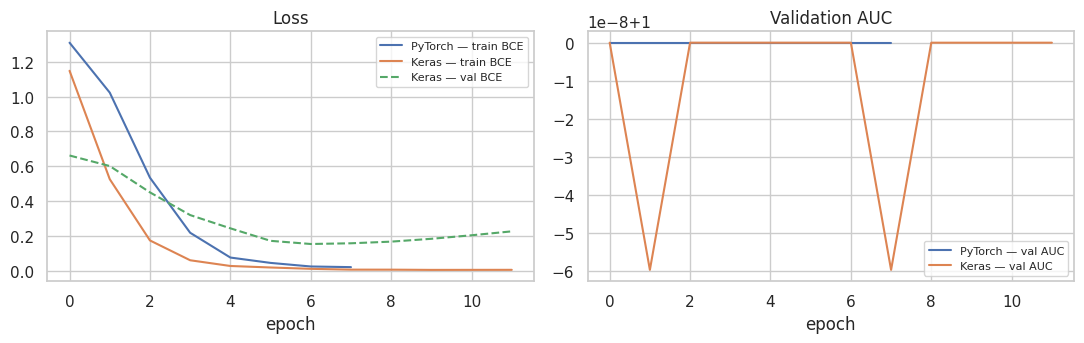

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(history_torch["loss"], label="PyTorch — train BCE")
axes[0].plot(history_k.history["loss"], label="Keras — train BCE")
axes[0].plot(history_k.history["val_loss"], label="Keras — val BCE", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend(fontsize=8)

axes[1].plot(history_torch["val_auc"], label="PyTorch — val AUC")
axes[1].plot(history_k.history["val_auc"], label="Keras — val AUC")
axes[1].set_title("Validation AUC")
axes[1].set_xlabel("epoch")
axes[1].legend(fontsize=8)

fig.tight_layout()


## Conclusions

- Both frameworks converge on the synthetic dataset and reach near-perfect
  AUC, which is expected because the bot generator deliberately produces
  discriminable streams (the synthetic distribution exaggerates the
  differences relative to real traffic).
- The point of this notebook is the **end-to-end pipeline**: a working
  Conv1D+BiLSTM feature pipeline ready to plug into the production
  behavioural-biometrics corpus once it exists.
- When real data lands, swap `synth.make_sequence_dataset(...)` for the
  PostgreSQL → Parquet exporter described in `tasks.md` §18.1; the rest
  of the architecture remains unchanged.
- Saved artifacts:
  - `models/seq_pytorch.pt`
  - `models/seq_keras.keras`

Continue to **`06_evaluation_and_export.ipynb`** for the consolidated
comparison, threshold tuning and winner export.
